<a href="https://colab.research.google.com/github/nithisharul/NN-from-Scratch/blob/main/NN_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np

In [4]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt


In [8]:
data = pd.read_csv('mnist_train.csv')

In [22]:
Y_train = Y_train.astype(int)


In [23]:
data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
data_train = np.array(data)

In [11]:
data_train = data_train.T

In [12]:
m,n = data_train.shape

In [13]:
X_train = data_train[1:]

In [14]:
Y_train = data_train[0]

In [24]:
Y_train

array([5, 0, 4, ..., 7, 2, 8])

In [25]:
 X_train[:,0].shape

(784,)

In [26]:
def init_params():
    W1 = np.random.randn(10, 784) * 0.01
    b1 = np.zeros((10, 1))
    W2 = np.random.randn(10, 10) * 0.01
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(0, Z)

def ReLU_deriv(Z):
    return Z > 0

def softmax(Z):
    return np.exp(Z) / np.sum(np.exp(Z), axis=0, keepdims=True)

def one_hot(Y):
    one_hot_Y = np.zeros((Y.max() + 1, Y.size))
    one_hot_Y[Y, np.arange(Y.size)] = 1
    return one_hot_Y

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    N = X.shape[1]
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = dZ2.dot(A1.T) / N
    db2 = np.sum(dZ2, axis=1, keepdims=True) / N
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = dZ1.dot(X.T) / N
    db1 = np.sum(dZ1, axis=1, keepdims=True) / N
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def compute_loss(A2, Y):
    N = Y.size
    one_hot_Y = one_hot(Y)
    loss = -np.sum(one_hot_Y * np.log(A2 + 1e-8)) / N
    return loss

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    losses = []
    accuracies = []

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        loss = compute_loss(A2, Y)
        acc = get_accuracy(get_predictions(A2), Y)
        losses.append(loss)
        accuracies.append(acc)

        if i % 50 == 0:
            print(f"Iteration {i} | Loss: {loss:.4f} | Accuracy: {acc:.4f}")

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(losses)
    plt.title("Loss")
    plt.xlabel("Iteration")
    plt.ylabel("Cross entropy loss")
    plt.subplot(1, 2, 2)
    plt.plot(accuracies)
    plt.title("Accuracy")
    plt.xlabel("Iteration")
    plt.ylabel("Accuracy")
    plt.tight_layout()
    plt.show()

    return W1, b1, W2, b2

Iteration 0 | Loss: nan | Accuracy: 0.0728
Iteration 50 | Loss: nan | Accuracy: 0.0966
Iteration 100 | Loss: nan | Accuracy: 0.0966
Iteration 150 | Loss: nan | Accuracy: 0.0966
Iteration 200 | Loss: nan | Accuracy: 0.0966
Iteration 250 | Loss: nan | Accuracy: 0.0966
Iteration 300 | Loss: nan | Accuracy: 0.0966
Iteration 350 | Loss: nan | Accuracy: 0.0966
Iteration 400 | Loss: nan | Accuracy: 0.0966
Iteration 450 | Loss: nan | Accuracy: 0.0966


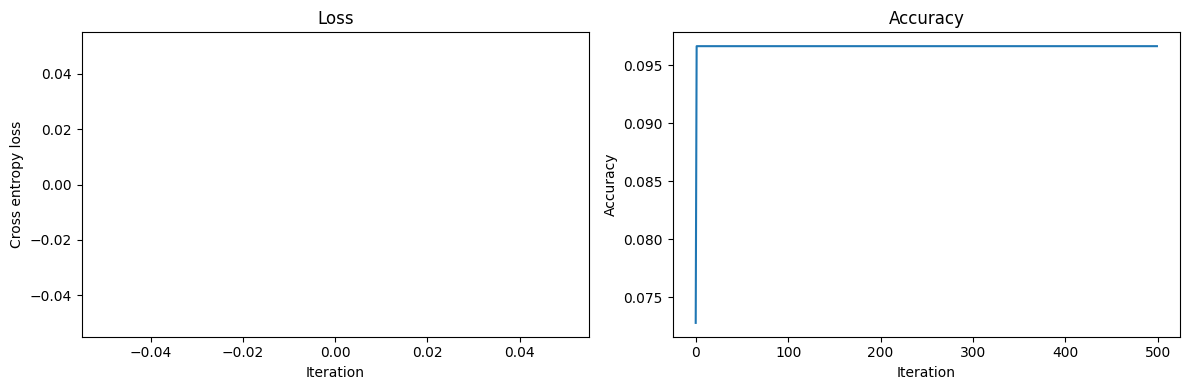

In [27]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, iterations=500, alpha=0.1)

In [38]:
def get_batch(X, Y, batch_size=256):
    idx = np.random.choice(X.shape[1], batch_size, replace=False)
    return X[:, idx], Y[idx]

def gradient_descent_lr(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    losses = []
    for i in range(iterations):
        X_batch, Y_batch = get_batch(X, Y)
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X_batch)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X_batch, Y_batch)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        loss = compute_loss(A2, Y_batch)
        losses.append(loss if np.isfinite(loss) else None)
    return losses

def gradient_descent_init(X, Y, iterations, alpha, init_type):
    if init_type == "zeros":
        W1, b1 = np.zeros((10, 784)), np.zeros((10, 1))
        W2, b2 = np.zeros((10, 10)), np.zeros((10, 1))
    elif init_type == "large":
        W1, b1 = np.random.randn(10, 784) * 10, np.zeros((10, 1))
        W2, b2 = np.random.randn(10, 10) * 10, np.zeros((10, 1))
    else:
        W1, b1 = np.random.randn(10, 784) * 0.01, np.zeros((10, 1))
        W2, b2 = np.random.randn(10, 10) * 0.01, np.zeros((10, 1))
    losses = []
    for i in range(iterations):
        X_batch, Y_batch = get_batch(X, Y)
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X_batch)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X_batch, Y_batch)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        loss = compute_loss(A2, Y_batch)
        losses.append(loss if np.isfinite(loss) else None)
    return losses

def gradient_descent_sigmoid(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    losses = []
    for i in range(iterations):
        X_batch, Y_batch = get_batch(X, Y)
        Z1, A1, Z2, A2 = forward_prop_sigmoid(W1, b1, W2, b2, X_batch)
        dW1, db1, dW2, db2 = back_prop_sigmoid(Z1, A1, Z2, A2, W2, X_batch, Y_batch)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        loss = compute_loss(A2, Y_batch)
        losses.append(loss if np.isfinite(loss) else None)
    return losses

def gradient_descent_adam(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    mW1, mb1, mW2, mb2 = np.zeros_like(W1), np.zeros_like(b1), np.zeros_like(W2), np.zeros_like(b2)
    vW1, vb1, vW2, vb2 = np.zeros_like(W1), np.zeros_like(b1), np.zeros_like(W2), np.zeros_like(b2)
    beta1, beta2, epsilon = 0.9, 0.999, 1e-8
    losses = []
    for i in range(1, iterations + 1):
        X_batch, Y_batch = get_batch(X, Y)
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X_batch)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X_batch, Y_batch)
        mW1 = beta1*mW1 + (1-beta1)*dW1
        mb1 = beta1*mb1 + (1-beta1)*db1
        mW2 = beta1*mW2 + (1-beta1)*dW2
        mb2 = beta1*mb2 + (1-beta1)*db2
        vW1 = beta2*vW1 + (1-beta2)*dW1**2
        vb1 = beta2*vb1 + (1-beta2)*db1**2
        vW2 = beta2*vW2 + (1-beta2)*dW2**2
        vb2 = beta2*vb2 + (1-beta2)*db2**2
        mW1_c = mW1/(1-beta1**i); mb1_c = mb1/(1-beta1**i)
        mW2_c = mW2/(1-beta1**i); mb2_c = mb2/(1-beta1**i)
        vW1_c = vW1/(1-beta2**i); vb1_c = vb1/(1-beta2**i)
        vW2_c = vW2/(1-beta2**i); vb2_c = vb2/(1-beta2**i)
        W1 = W1 - alpha*mW1_c/(np.sqrt(vW1_c)+epsilon)
        b1 = b1 - alpha*mb1_c/(np.sqrt(vb1_c)+epsilon)
        W2 = W2 - alpha*mW2_c/(np.sqrt(vW2_c)+epsilon)
        b2 = b2 - alpha*mb2_c/(np.sqrt(vb2_c)+epsilon)
        loss = compute_loss(A2, Y_batch)
        losses.append(loss if np.isfinite(loss) else None)
    return losses

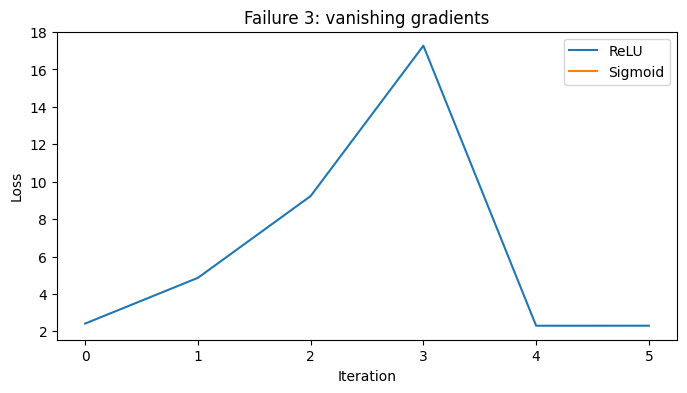

In [39]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_deriv(Z):
    s = sigmoid(Z)
    return s * (1 - s)

def forward_prop_sigmoid(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = sigmoid(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def back_prop_sigmoid(Z1, A1, Z2, A2, W2, X, Y):
    N = X.shape[1]
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = dZ2.dot(A1.T) / N
    db2 = np.sum(dZ2, axis=1, keepdims=True) / N
    dZ1 = W2.T.dot(dZ2) * sigmoid_deriv(Z1)
    dW1 = dZ1.dot(X.T) / N
    db1 = np.sum(dZ1, axis=1, keepdims=True) / N
    return dW1, db1, dW2, db2

def gradient_descent_sigmoid(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    losses = []
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop_sigmoid(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop_sigmoid(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        loss = compute_loss(A2, Y)
        losses.append(loss if np.isfinite(loss) else None)
    return losses

losses_relu    = gradient_descent_lr(X_train, Y_train, 500, 0.1)
losses_sigmoid = gradient_descent_sigmoid(X_train, Y_train, 500, 0.1)

plt.figure(figsize=(8, 4))
plt.plot(losses_relu, label="ReLU")
plt.plot(losses_sigmoid, label="Sigmoid")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Failure 3: vanishing gradients")
plt.legend()
plt.show()

In [40]:
losses_sgd_large = gradient_descent_lr(X_train, Y_train, 500, 10)
losses_sgd_small = gradient_descent_lr(X_train, Y_train, 500, 0.00001)
losses_sgd_good  = gradient_descent_lr(X_train, Y_train, 500, 0.1)
losses_adam_large = gradient_descent_adam(X_train, Y_train, 500, 10)
losses_adam_small = gradient_descent_adam(X_train, Y_train, 500, 0.00001)
losses_adam_good  = gradient_descent_adam(X_train, Y_train, 500, 0.001)


/tmp/ipykernel_3723/2948915576.py:15: RuntimeWarning: overflow encountered in exp
  return np.exp(Z) / np.sum(np.exp(Z), axis=0, keepdims=True)
/tmp/ipykernel_3723/2948915576.py:15: RuntimeWarning: invalid value encountered in divide
  return np.exp(Z) / np.sum(np.exp(Z), axis=0, keepdims=True)


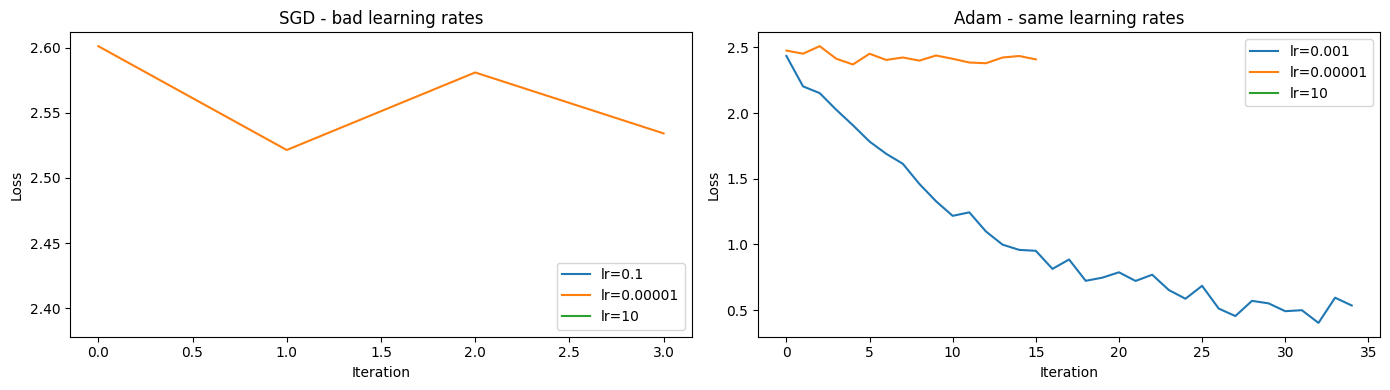

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(losses_sgd_good, label="lr=0.1")
axes[0].plot(losses_sgd_small, label="lr=0.00001")
axes[0].plot(losses_sgd_large, label="lr=10")
axes[0].set_title("SGD - bad learning rates")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(losses_adam_good, label="lr=0.001")
axes[1].plot(losses_adam_small, label="lr=0.00001")
axes[1].plot(losses_adam_large, label="lr=10")
axes[1].set_title("Adam - same learning rates")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_3723/2948915576.py:15: RuntimeWarning: overflow encountered in exp
  return np.exp(Z) / np.sum(np.exp(Z), axis=0, keepdims=True)
/tmp/ipykernel_3723/2948915576.py:15: RuntimeWarning: invalid value encountered in divide
  return np.exp(Z) / np.sum(np.exp(Z), axis=0, keepdims=True)


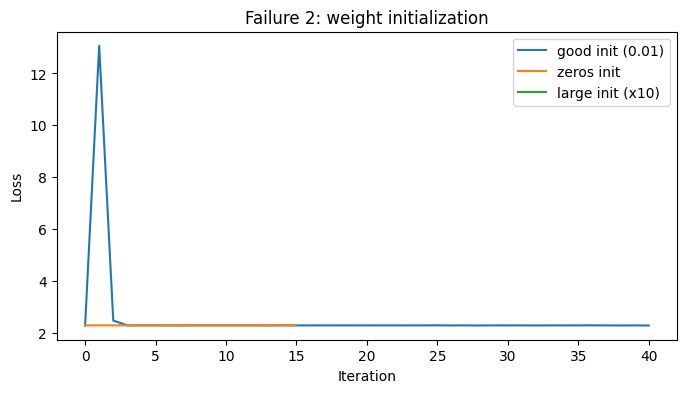

In [42]:
losses_zeros = gradient_descent_init(X_train, Y_train, 500, 0.1, "zeros")
losses_large = gradient_descent_init(X_train, Y_train, 500, 0.1, "large")
losses_good  = gradient_descent_init(X_train, Y_train, 500, 0.1, "good")

plt.figure(figsize=(8, 4))
plt.plot(losses_good, label="good init (0.01)")
plt.plot(losses_zeros, label="zeros init")
plt.plot(losses_large, label="large init (x10)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Failure 2: weight initialization")
plt.legend()
plt.show()

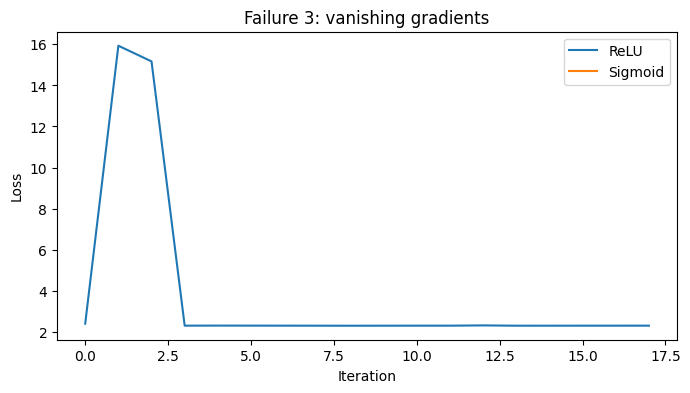

In [43]:
losses_relu    = gradient_descent_lr(X_train, Y_train, 500, 0.1)
losses_sigmoid = gradient_descent_sigmoid(X_train, Y_train, 500, 0.1)

plt.figure(figsize=(8, 4))
plt.plot(losses_relu, label="ReLU")
plt.plot(losses_sigmoid, label="Sigmoid")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Failure 3: vanishing gradients")
plt.legend()
plt.show()